In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
X = np.array([1, 3, 4, 6, 7])    # experience (in year)
y = np.array([15, 35, 45, 65, 75])  # salary ( in thousand)

In [3]:
np.zeros(X.shape[0])

array([0., 0., 0., 0., 0.])

In [4]:
#Prediction Function

def make_predict(X, y, w, b):
    m = X.shape[0]      # kotogulo data point ache
    predictions = np.zeros((m,))    #joto gulo datapoint initially toto gulo zeros(empty array)

    for i in range(m):
        predictions[i] = w*X[i]+b   # y = wx+b

    return predictions

In [5]:
predictions = make_predict(X, y, 0, 0)
print(predictions)

[0. 0. 0. 0. 0.]


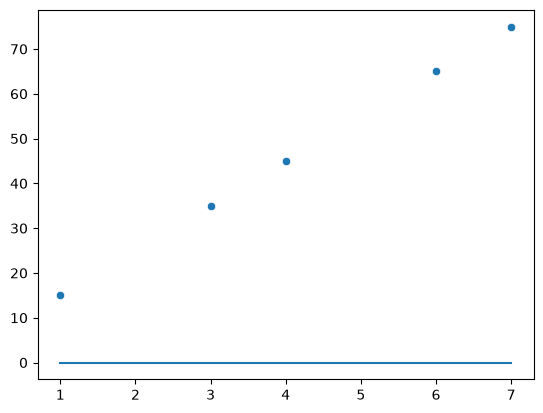

In [6]:
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

[1. 3. 4. 6. 7.]


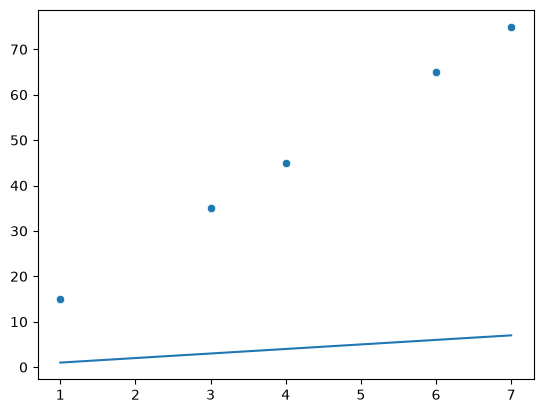

In [7]:
predictions = make_predict(X, y, w=1, b=0)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

[ 8. 18. 23. 33. 38.]


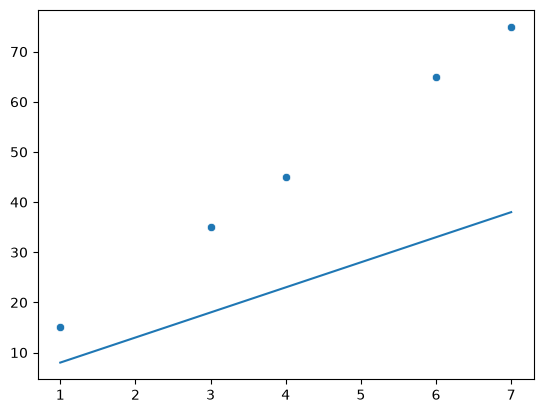

In [8]:
predictions = make_predict(X, y, w=5, b=3)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

[15. 35. 45. 65. 75.]


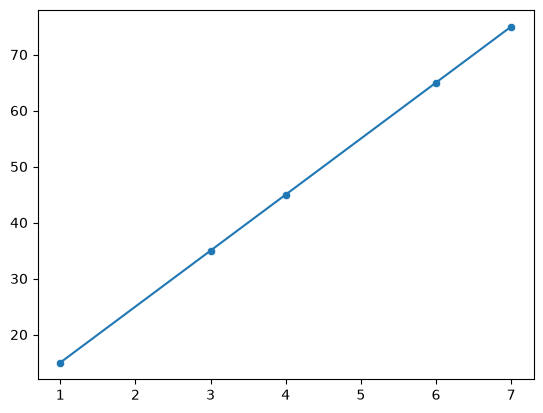

In [9]:
predictions = make_predict(X, y, w=10, b=5)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

# Cost Function

In [10]:
def compute_cost (X,y,w,b):
    m = X.shape[0]      # kotogulo data point ache
    total_cost = 0.0
    for i in range(m):
        predictions = w*X[i]+b   # y = wx+b
        error = predictions - y[i]  # (y^ - y)
        total_cost += error**2    #error^2
    cost = (total_cost/(2*m))
    return cost

In [11]:
print(compute_cost(X, y, w=5, b=0))
print(compute_cost(X, y, w=10, b=5))

395.0
0.0


[0. 0. 0. 0. 0.]


Text(0.5, 1.0, 'Cost: 1332.5, for w=0.0 and b =0.0')

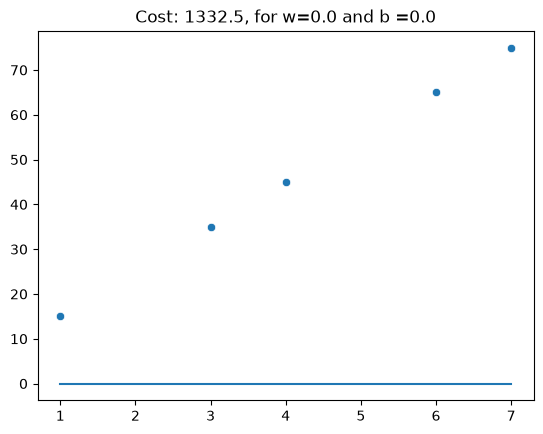

In [13]:
w=0.0
b=0.0

predictions = make_predict(X, y, w=w, b=b)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=w)}, for w={w} and b ={b}")

[1. 3. 4. 6. 7.]


Text(0.5, 1.0, 'Cost: 1058.3, for w=1.0 and b =0.0')

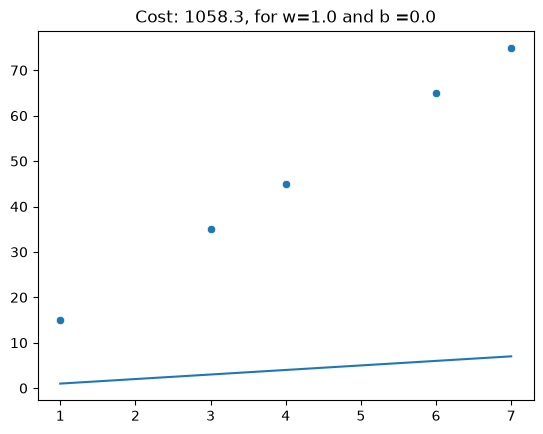

In [14]:
w=1.0
b=0.0

predictions = make_predict(X, y, w=w, b=b)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=w)}, for w={w} and b ={b}")

[ 3.  7.  9. 13. 15.]


Text(0.5, 1.0, 'Cost: 815.7, for w=2.0 and b =1.0')

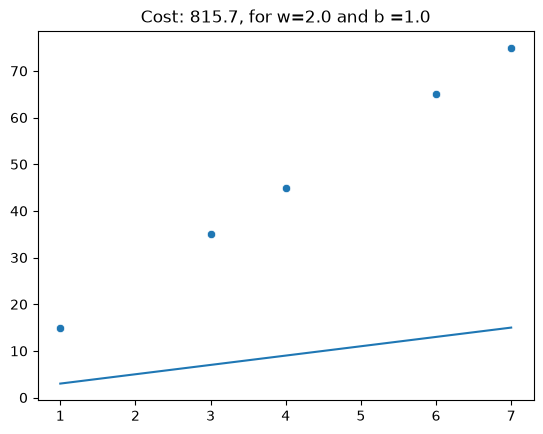

In [15]:
w=2.0
b=1.0

predictions = make_predict(X, y, w=w, b=b)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=w)}, for w={w} and b ={b}")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 0.0, for w=10.0 and b =5.0')

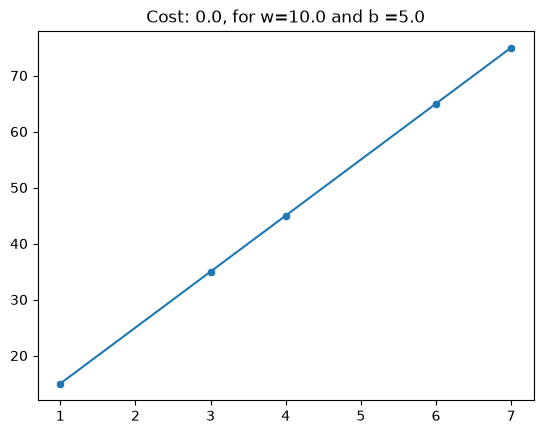

In [16]:
w=10.0
b=5.0

predictions = make_predict(X, y, w=w, b=b)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w={w} and b ={b}")

Text(0, 0.5, 'cost - J(w)')

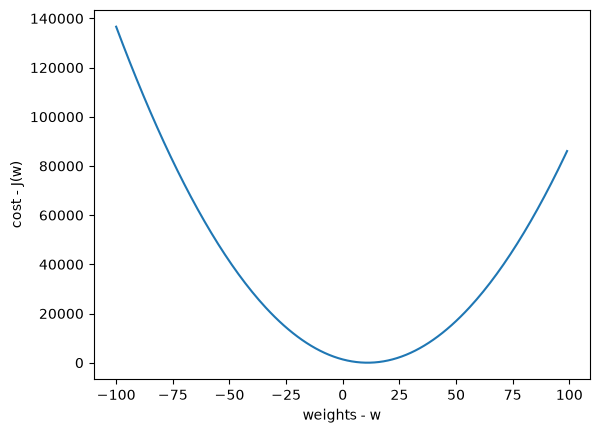

In [17]:
cost = []
w = []


for i in range(-100,100):
    cost_i = compute_cost(X,y,w=i,b=0)
    w.append(i)
    cost.append(cost_i)

plt.plot(w,cost)
plt.xlabel("weights - w")
plt.ylabel("cost - J(w)")

# Gradient Dicent

In [ ]:
def calculate_gradient(X,y, w,b):
    m = X.shape[0]      # kotogulo data point ache
    dj_dw = 0           # Change needed for weight
    dj_db = 0           # Change neede for bias
    for i in range(m):
        predictions = w*X[i]+b   # y = wx+b
        error = predictions - y[i]

        # Multiply error by X[i] for the weight gradient
        dj_dw = dj_dw + (error*X[i])

        # The bias gradient is just the sum of errors
        dj_db = dj_db + (error)
    dj_dw = dj_dw / m 
    dj_db = dj_db / m
    return dj_dw, dj_db

In [19]:
calculate_gradient(X,y, w=-5,b=0)

(np.float64(-354.0), np.float64(-68.0))

# Cost Optimization by using Gradient Descent

In [ ]:
def gradient_decent(X, y, w_input, b_input, max_iter, alpha=0.01):
    """Automates the tuning of w and b to minimize cost"""
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []
    for i in range(max_iter):
        # 1. Calculate the dradients(the slope)
        dj_dw, dj_db = calculate_gradient(X,y, w,b)


        # 2. update parameters by taking a small step(alpha) against the gradient
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # 3. Track progress by saving the cost
        cost = compute_cost(X, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)

        #Log the status every 100 steps
        if i % 100 == 0:
            print(f"iteration{i}, w:{w:0.4f}, b:{b:0.4f}, dj_dw:{dj_dw:0.4f}, dj_db:{dj_db:0.4f}, cost:{cost:0.4f}")

    return w, b, cost_memo, iteration

In [22]:
w_final, b_final, cost_memo, iter = gradient_decent(X, y, w_input = 0, b_input = 0, max_iter = 1000, alpha = 0.01)

iteration0, w:2.4300, b:0.4700, dj_dw:-243.0000, dj_db:-47.0000, cost:790.3717
iteration100, w:10.4659, b:2.5593, dj_dw:0.0926, dj_db:-0.4848, cost:0.6120
iteration200, w:10.3821, b:2.9986, dj_dw:0.0759, dj_db:-0.3976, cost:0.4115
iteration300, w:10.3133, b:3.3588, dj_dw:0.0622, dj_db:-0.3260, cost:0.2767
iteration400, w:10.2569, b:3.6542, dj_dw:0.0510, dj_db:-0.2673, cost:0.1861
iteration500, w:10.2107, b:3.8965, dj_dw:0.0418, dj_db:-0.2192, cost:0.1251
iteration600, w:10.1727, b:4.0951, dj_dw:0.0343, dj_db:-0.1798, cost:0.0841
iteration700, w:10.1416, b:4.2580, dj_dw:0.0281, dj_db:-0.1474, cost:0.0566
iteration800, w:10.1162, b:4.3915, dj_dw:0.0231, dj_db:-0.1209, cost:0.0380
iteration900, w:10.0952, b:4.5010, dj_dw:0.0189, dj_db:-0.0991, cost:0.0256


10.078258287598194 4.5900429495621635
[14.66830124 34.82481781 44.9030761  65.05959268 75.13785096]


Text(0.5, 1.0, 'Cost: 0.0172661285399435, for w=10.078258287598194 and b =4.5900429495621635')

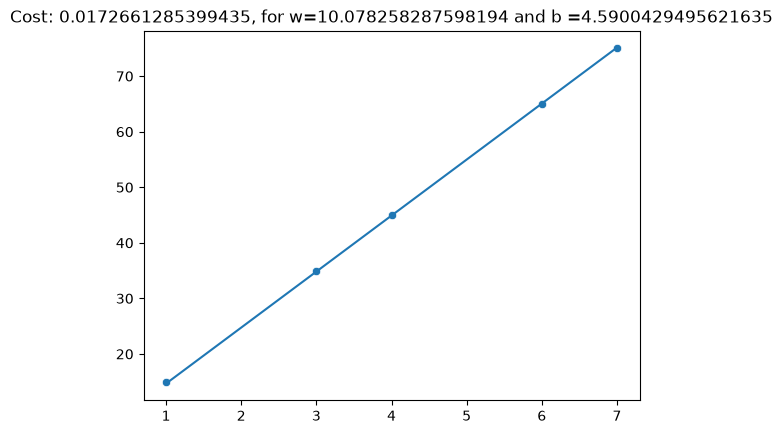

In [23]:
print(w_final,b_final)
predictions = make_predict(X, y, w=w_final, b=b_final)
print(predictions)
sns.scatterplot(x=X, y=y)
plt.plot(X, predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w_final,b=b_final)}, for w={w_final} and b ={b_final}")